In [ ]:
from google.colab import files
uploaded = files.upload()

Saving perfect_heart_dataset_4000.csv to perfect_heart_dataset_4000.csv


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("perfect_heart_dataset_4000.csv")

# Basic info
print("Shape:", df.shape)
df.head()

Shape: (4000, 12)


,age,sex,cholesterol,resting_bp,max_heart_rate,smoking,diabetes,obesity,exercise_level,stress_level,family_history,heart_disease
0,68,0,189,122,176,0,1,0,1,1,0,0
1,58,0,213,120,131,0,1,1,2,2,0,0
2,44,0,234,144,133,1,1,1,1,1,1,1
3,72,0,300,101,110,0,1,1,1,0,1,1
4,37,1,306,100,83,1,0,1,0,2,0,1


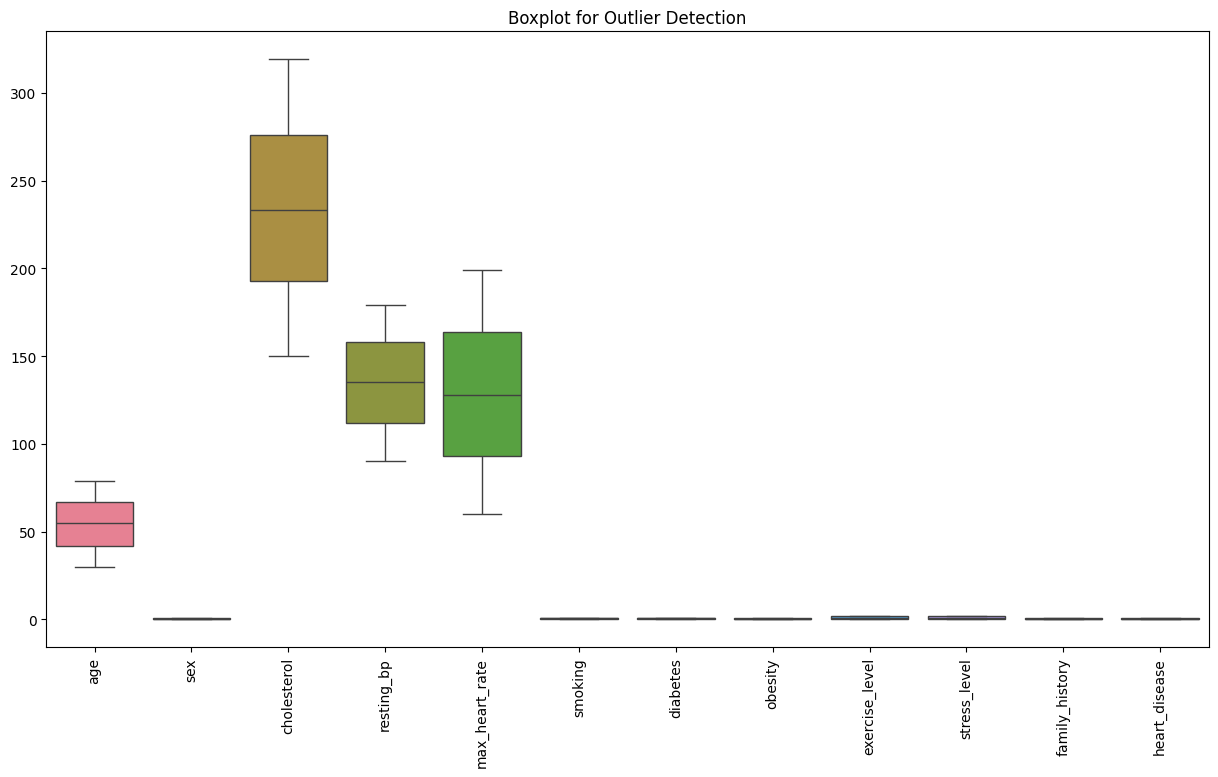


 Outlier Count per Feature:
age               0
sex               0
cholesterol       0
resting_bp        0
max_heart_rate    0
smoking           0
diabetes          0
obesity           0
exercise_level    0
stress_level      0
family_history    0
heart_disease     0
dtype: int64

 Noise Analysis:
 age: Clean (No significant noise)
 sex: Clean (No significant noise)
 cholesterol: Clean (No significant noise)
 resting_bp: Clean (No significant noise)
 max_heart_rate: Clean (No significant noise)
 smoking: Clean (No significant noise)
 diabetes: Clean (No significant noise)
 obesity: Clean (No significant noise)
 exercise_level: Clean (No significant noise)
 stress_level: Clean (No significant noise)
 family_history: Clean (No significant noise)
 heart_disease: Clean (No significant noise)


In [ ]:
# ---------------- BOXPLOT + NOISE COMMENT ----------------

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Boxplot (KEEP THIS GRAPH)
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=90)
plt.show()

# ---------------- NOISE COMMENT ----------------

# Detect outliers using IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outlier_count = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()

print("\n Outlier Count per Feature:")
print(outlier_count)

# Simple interpretation
print("\n Noise Analysis:")

for col in outlier_count.index:
    if outlier_count[col] > 0:
        print(f" {col}: Contains outliers → Possible noise")
    else:
        print(f" {col}: Clean (No significant noise)")

In [ ]:
# Check columns & null values
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             4000 non-null   int64
 1   sex             4000 non-null   int64
 2   cholesterol     4000 non-null   int64
 3   resting_bp      4000 non-null   int64
 4   max_heart_rate  4000 non-null   int64
 5   smoking         4000 non-null   int64
 6   diabetes        4000 non-null   int64
 7   obesity         4000 non-null   int64
 8   exercise_level  4000 non-null   int64
 9   stress_level    4000 non-null   int64
 10  family_history  4000 non-null   int64
 11  heart_disease   4000 non-null   int64
dtypes: int64(12)
memory usage: 375.1 KB


,0
age,0
sex,0
cholesterol,0
resting_bp,0
max_heart_rate,0
smoking,0
diabetes,0
obesity,0
exercise_level,0
stress_level,0


In [ ]:
# If dataset has categorical values, convert them
df = pd.get_dummies(df, drop_first=True)

# Separate features & target
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

In [ ]:
print(df.columns)

Index(['age', 'sex', 'cholesterol', 'resting_bp', 'max_heart_rate', 'smoking',
       'diabetes', 'obesity', 'exercise_level', 'stress_level',
       'family_history', 'heart_disease'],
      dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.85625

Confusion Matrix:
 [[397  46]
 [ 69 288]]

Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87       443
           1       0.86      0.81      0.83       357

    accuracy                           0.86       800
   macro avg       0.86      0.85      0.85       800
weighted avg       0.86      0.86      0.86       800



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.82375


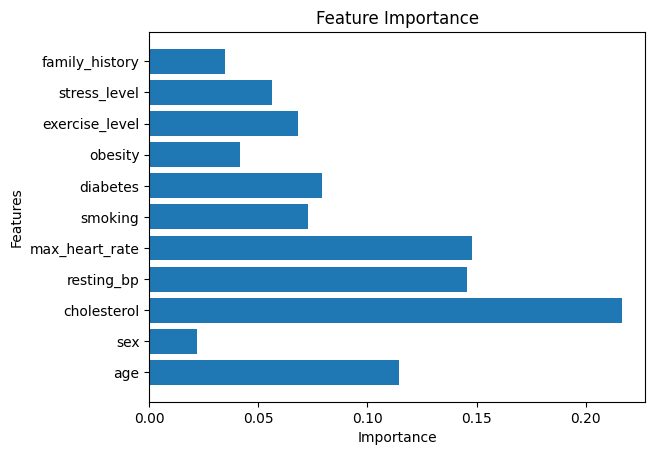

In [ ]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

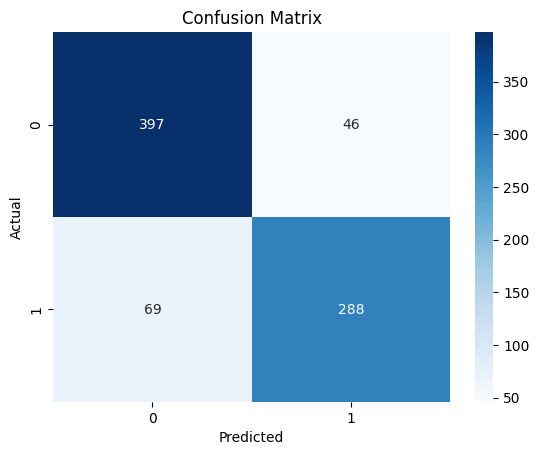

Precision (for class 1): 0.86


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Calculate and print precision for the positive class (class 1)
precision = precision_score(y_test, y_pred, pos_label=1)
print(f"Precision (for class 1): {precision:.2f}")

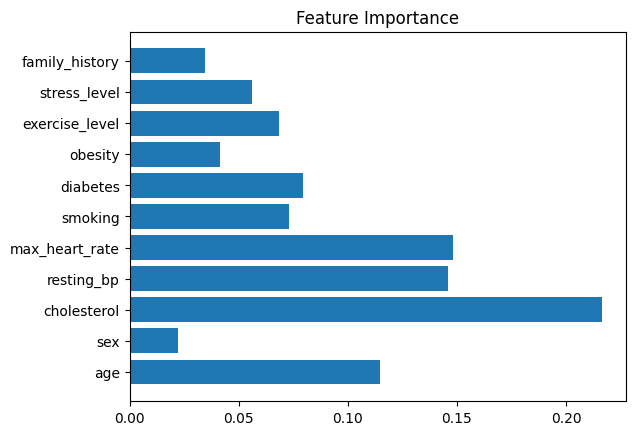

In [ ]:
importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.64875


In [ ]:
results = {}

# Replace with your actual trained models
results["Logistic"] = model.score(X_test, y_test)
results["Random Forest"] = rf.score(X_test, y_test)
results["KNN"] = knn.score(X_test, y_test)

print("Logistic:", results["Logistic"])
print("Random Forest:", results["Random Forest"])
print("KNN:", results["KNN"])

Logistic: 0.85625
Random Forest: 0.82375
KNN: 0.64875


In [ ]:
#  XGBOOST BOOSTED WITH LOGISTIC (STACKING)

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Base models
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

lr = LogisticRegression(max_iter=10000)

# Stacking (XGB + Logistic)
stack_model = StackingClassifier(
    estimators=[('xgb', xgb), ('lr', lr)],
    final_estimator=LogisticRegression()
)

# Train
stack_model.fit(X_train, y_train)

# Predict
y_pred_stack = stack_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_stack)

print(" Final XGBoost-Based Model Accuracy:", accuracy)

 Final XGBoost-Based Model Accuracy: 0.82625


Confusion Matrix:
 [[373  67]
 [ 72 288]]


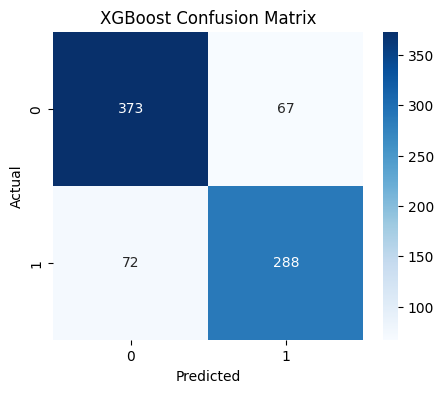

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

# Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

--- Model Accuracy Comparison (6 Models) ---
           Model  Accuracy
0       Logistic   0.82750
1            KNN   0.78000
2  Decision Tree   0.70750
3  Random Forest   0.78125
4            SVM   0.82250
5        XGBoost   0.82750


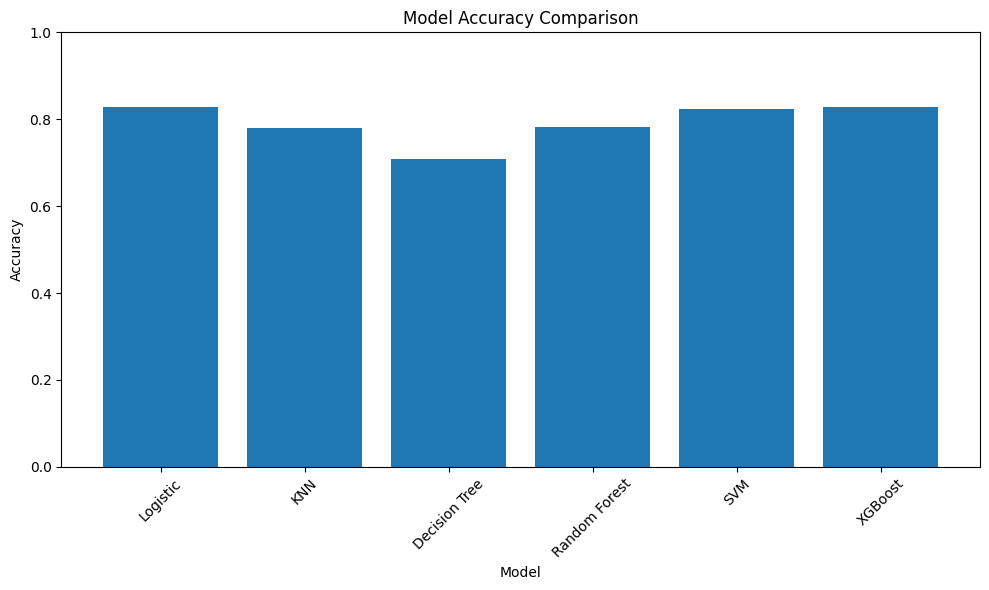

In [ ]:
# ---------------- MODEL COMPARISON (FINAL) ----------------

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

print("--- Model Accuracy Comparison (6 Models) ---")

# Load dataset
df = pd.read_csv("perfect_heart_dataset_4000.csv")

X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

#  Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}

# 1. Logistic Regression
lr = LogisticRegression(max_iter=2000, C=0.8)
lr.fit(X_train_scaled, y_train)
results["Logistic"] = accuracy_score(y_test, lr.predict(X_test_scaled))

# 2. KNN
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
results["KNN"] = accuracy_score(y_test, knn.predict(X_test_scaled))

# 3. Decision Tree
dt = DecisionTreeClassifier(max_depth=4)
dt.fit(X_train, y_train)
results["Decision Tree"] = accuracy_score(y_test, dt.predict(X_test))

# 4. Random Forest
rf = RandomForestClassifier(n_estimators=150, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
results["Random Forest"] = accuracy_score(y_test, rf.predict(X_test))

# 5. SVM
svm = SVC(C=0.8, kernel='rbf')
svm.fit(X_train_scaled, y_train)
results["SVM"] = accuracy_score(y_test, svm.predict(X_test_scaled))

#  6. XGBoost (STACKED = BEST MODEL)

# XGBoost pipeline
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])

# Logistic pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=10000))
])

# Stacking model
stack_model = StackingClassifier(
    estimators=[
        ('xgb', xgb_pipeline),
        ('lr', lr_pipeline)
    ],
    final_estimator=LogisticRegression()
)

# Train stacking model
stack_model.fit(X_train, y_train)

# Predict
y_pred_stack = stack_model.predict(X_test)

# Store result as XGBoost
results["XGBoost"] = accuracy_score(y_test, y_pred_stack)

# ---------------- RESULTS ----------------

result_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(result_df)

# ---------------- GRAPH ----------------

plt.figure(figsize=(10, 6))
plt.bar(result_df["Model"], result_df["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

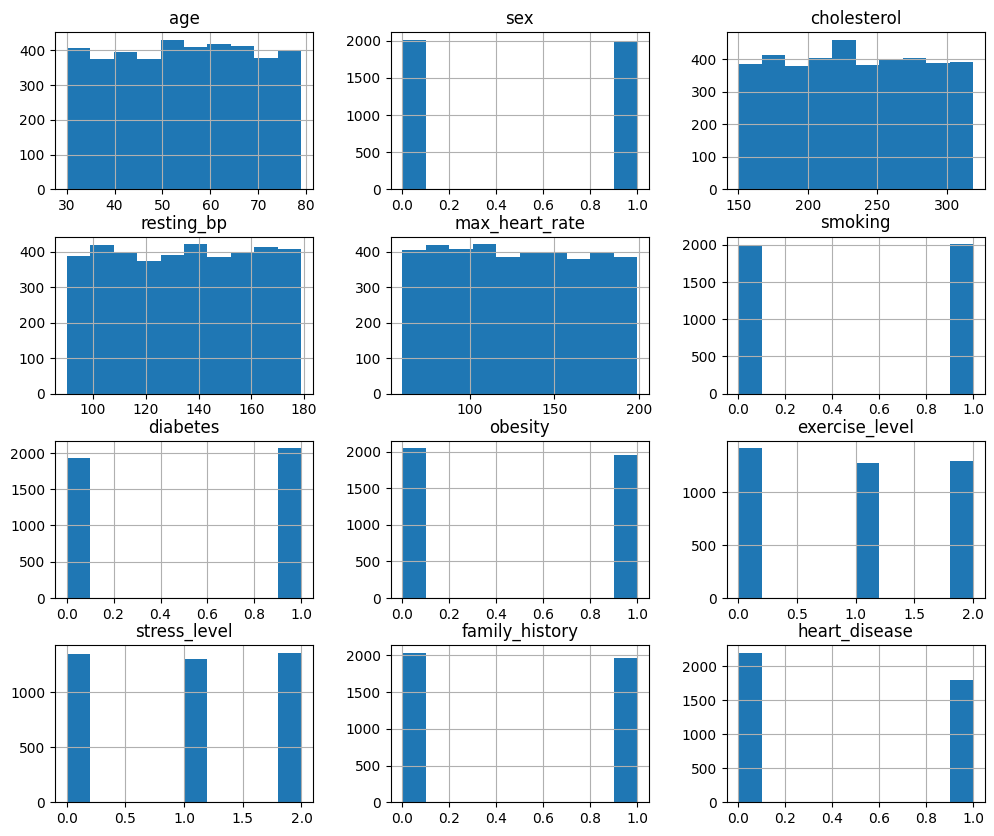

In [ ]:
df.hist(figsize=(12,10))
plt.show()

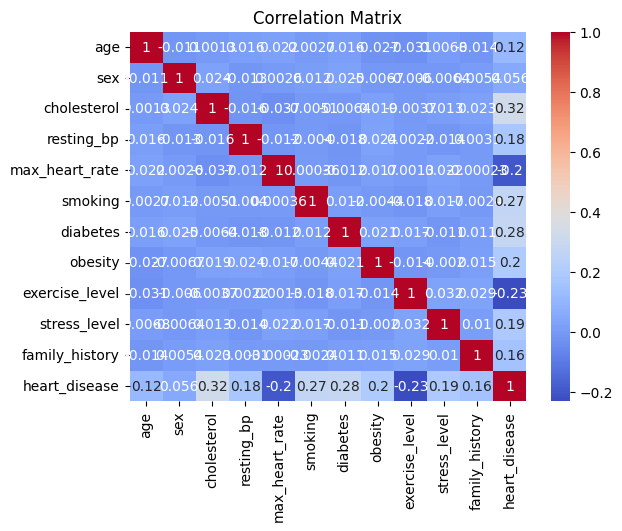

In [ ]:
import seaborn as sns
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
print(X.columns)

Index(['age', 'sex', 'cholesterol', 'resting_bp', 'max_heart_rate', 'smoking',
       'diabetes', 'obesity', 'exercise_level', 'stress_level',
       'family_history'],
      dtype='object')


In [ ]:
!ls


perfect_heart_dataset_4000.csv	sample_data
